In [2]:
import os
import json

In [3]:
from dataset_processing_test import DatasetProcessing

In [4]:
base_path = os.path.join(os.getcwd(), "data")
datas = os.listdir(base_path)
dictionaries = []
for i in datas:
    print(i)
    data_dict = json.load(open(os.path.join(base_path, i)))
    dictionaries.append(data_dict)

data_ClUl.json
data_Jgwk.json
data_nOcZ.json
data_VFYr.json


In [5]:
processing = DatasetProcessing()

WORKING DIRECTORY::::f:\OE_Szakdoga\OE_Szakdolgozat\src\models\neural_networks\working


In [6]:
graphs = processing.create_graphs_and_labels(dictionaries, 10)

In [7]:
len(graphs[0])

110659

In [9]:
filtered_graphs = graphs[0][4:]
filtered_labels = graphs[1][4:]

In [10]:
graphs_sequences, label_sequences = processing.create_sequence_and_labels(
    filtered_graphs, filtered_labels, 5
)

In [11]:
len(graphs_sequences)

22131

In [12]:
filtered_graph_sequences=[]
filtered_label_sequences=[]
for i, graph_sequence in enumerate(graphs_sequences):
    good_sequence=True
    for g in graph_sequence:
        if g.x.shape[0]==1:
            good_sequence=False
    if good_sequence:
        filtered_graph_sequences.append(graph_sequence)
        filtered_label_sequences.append(label_sequences[i])


In [13]:
graph_sequence=filtered_graph_sequences
label_sequences=filtered_label_sequences

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import numpy as np


class GNNEncoder(nn.Module):
    """
    Graph Neural Network encoder that processes individual graphs.
    """

    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNNEncoder, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # First GNN layer with ReLU activation
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        # Second GNN layer
        x = self.conv2(x, edge_index)

        return x


class TemporalGraphModel(nn.Module):
    """
    A model that processes a sequence of graphs and makes predictions for each node in the last graph.
    """

    def __init__(self, node_features, hidden_dim, gru_hidden_dim, output_dim):
        super(TemporalGraphModel, self).__init__()

        # GNN for processing individual graphs
        self.graph_encoder = GNNEncoder(node_features, hidden_dim, hidden_dim)

        # GRU for processing the sequence of graph embeddings
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=gru_hidden_dim,
            num_layers=1,
            batch_first=True,
        )

        # Prediction heads for two different classes
        self.predictor1 = nn.Sequential(
            nn.Linear(gru_hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

        self.predictor2 = nn.Sequential(
            nn.Linear(gru_hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, graph_sequence):
        """
        Process a sequence of graphs and make predictions for nodes in the last graph.

        Args:
            graph_sequence (list): List of PyTorch Geometric Data objects

        Returns:
            tuple: Two torch.Tensor predictions for each node in the last graph (excluding the first node)
        """
        # Check if we have the expected number of graphs
        if len(graph_sequence) != 5:
            raise ValueError(
                f"Expected 5 graphs in sequence, but got {len(graph_sequence)}"
            )

        # Process each graph to get node embeddings
        sequence_embeddings = []
        for graph in graph_sequence:
            # Process the graph with GNN
            node_embeddings = self.graph_encoder(graph.x, graph.edge_index)
            sequence_embeddings.append(node_embeddings)

        # Get the number of nodes in the last graph
        last_graph_nodes = graph_sequence[-1].x.size(0)

        # Prepare GRU input for each node in the last graph, skipping the first node
        gru_inputs = []
        for node_idx in range(
            1, last_graph_nodes
        ):  # Start from 1 to skip the first node
            # For each node in the last graph, collect its features across time
            node_sequence = []
            for t in range(len(sequence_embeddings)):
                # Handle the case where earlier graphs might have fewer nodes
                if node_idx < sequence_embeddings[t].size(0):
                    node_sequence.append(sequence_embeddings[t][node_idx])
                else:
                    # If the node doesn't exist in earlier graphs, use zero embedding
                    node_sequence.append(torch.zeros_like(sequence_embeddings[-1][0]))

            # Stack the node's embeddings across time
            node_sequence = torch.stack(node_sequence, dim=0).unsqueeze(
                0
            )  # [1, seq_len, hidden_dim]
            gru_inputs.append(node_sequence)

        # Process each node's temporal sequence through the GRU
        node_predictions1 = []
        node_predictions2 = []
        for node_input in gru_inputs:
            # Process through GRU
            gru_out, _ = self.gru(node_input)

            # Take the last output and make predictions
            final_embedding = gru_out[:, -1, :]  # [1, hidden_dim]
            prediction1 = self.predictor1(final_embedding)
            prediction2 = self.predictor2(final_embedding)
            node_predictions1.append(prediction1)
            node_predictions2.append(prediction2)

        # Stack all node predictions
        return torch.cat(node_predictions1, dim=0), torch.cat(
            node_predictions2, dim=0
        )  # [num_nodes-1, output_dim]


def process_graph_sequence(graph_list):
    """
    Process a sequence of 5 graphs and make predictions for nodes in the last graph.

    Args:
        graph_list (list): A list of 5 PyTorch Geometric graphs

    Returns:
        tuple: Two torch.Tensor predictions for each node in the last graph (excluding the first node)
    """
    # Initialize the model
    model = TemporalGraphModel(
        node_features=13,  # Number of features per node
        hidden_dim=64,  # Hidden dimension for GNN
        gru_hidden_dim=128,  # Hidden dimension for GRU
        output_dim=6,  # Output dimension (6 for each class)
    )

    # Forward pass
    predictions1, predictions2 = model(graph_list)

    return predictions1, predictions2

In [17]:
label_sequences

[[[1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4]],
 [[1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4]],
 [[1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4],
  [1, 4]],
 [[1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5]],
 [[1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5]],
 [[1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5]],
 [[1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5]],
 [[1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5],
  [1, 5]],
 [[1, 5],
  [1, 5],
  [1, 5],
  

In [67]:
filtered_graph_sequences=[]
filtered_label_sequences=[]
counter=0
for i,sequence in enumerate(label_sequences):
    if sequence[0][0]==0 and sequence[0][1]==5 and counter<1800:
        filtered_graph_sequences.append(graphs_sequences[i])
        filtered_label_sequences.append(label_sequences[i])
        counter+=1
    elif sequence[0][0]!=0 and sequence[0][1]!=5:
        filtered_graph_sequences.append(graphs_sequences[i])
        filtered_label_sequences.append(label_sequences[i])
        


In [68]:
len(graphs_sequences)

22131

In [18]:
new_label=[]
new_graph=[]
for i, sequence in enumerate(label_sequences):
    counter=0
    place=f"{sequence[0][0]}-{sequence[0][1]}"
    for label in new_label:
        place2=f"{label[0][0]}-{label[0][1]}"
        if place==place2:
            counter+=1
    if counter<150:
        new_label.append(sequence)
        new_graph.append(graphs_sequences[i])





In [19]:
graphs_sequences=new_graph
label_sequences=new_label


In [20]:
occurances=[]
for i in label_sequences:
    occurances.append(f"{i[0][0]}-{i[0][1]}")

import pandas as pd
df=pd.DataFrame(occurances,columns=["Label"])
df.value_counts()


Label
0-1      150
4-1      150
0-3      150
0-4      150
0-5      150
1-1      150
2-3      150
1-5      150
1-3      150
2-1      150
4-3      150
4-4      150
4-5      150
3-3      150
3-4      150
3-5      150
3-1      150
5-3       94
2-5       88
5-1       81
1-4       66
0-0       42
0-2       30
1-2       13
3-2       12
3-0        9
1-0        8
2-4        8
2-0        6
4-2        6
5-4        4
2-2        3
4-0        2
Name: count, dtype: int64

In [24]:
len(graphs_sequences)

3022

In [23]:
len(label_sequences)

3022

In [71]:
graphs_sequences=filtered_graph_sequences
label_sequences=filtered_label_sequences


In [53]:
48390/5

9678.0

In [54]:
14000/5

2800.0

In [16]:
for i, sequence in enumerate(label_sequences):
    label_sequences[i] = label_sequences[i][1:]

In [30]:
model = TemporalGraphModel(
        node_features=13,  # Number of features per node
        hidden_dim=64,  # Hidden dimension for GNN
        gru_hidden_dim=128,  # Hidden dimension for LSTM
        output_dim=6,  # Output dimension (6 for each class)
    )

Training set size: 2417 sequences
Test set size: 605 sequences
Epoch 1/50, Train Loss: 3.2226, Test Loss: 3.0432
Train Acc1: 22.86%, Train Acc2: 37.13%, Test Acc1: 21.69%, Test Acc2: 38.75%
Train F1-1: 0.1872, Train F1-2: 0.2268, Test F1-1: 0.1805, Test F1-2: 0.2320
Epoch 2/50, Train Loss: 2.9048, Test Loss: 2.7228
Train Acc1: 27.02%, Train Acc2: 55.26%, Test Acc1: 26.77%, Test Acc2: 50.90%
Train F1-1: 0.2333, Train F1-2: 0.5016, Test F1-1: 0.2226, Test F1-2: 0.4555
Epoch 3/50, Train Loss: 2.7011, Test Loss: 2.6019
Train Acc1: 27.45%, Train Acc2: 55.91%, Test Acc1: 27.56%, Test Acc2: 51.43%
Train F1-1: 0.2326, Train F1-2: 0.4893, Test F1-1: 0.2262, Test F1-2: 0.4274
Epoch 4/50, Train Loss: 2.6014, Test Loss: 2.4828
Train Acc1: 29.37%, Train Acc2: 62.01%, Test Acc1: 29.00%, Test Acc2: 57.74%
Train F1-1: 0.2615, Train F1-2: 0.5794, Test F1-1: 0.2550, Test F1-2: 0.5221
Epoch 5/50, Train Loss: 2.5477, Test Loss: 2.4470
Train Acc1: 29.79%, Train Acc2: 63.18%, Test Acc1: 30.57%, Test Acc2: 5

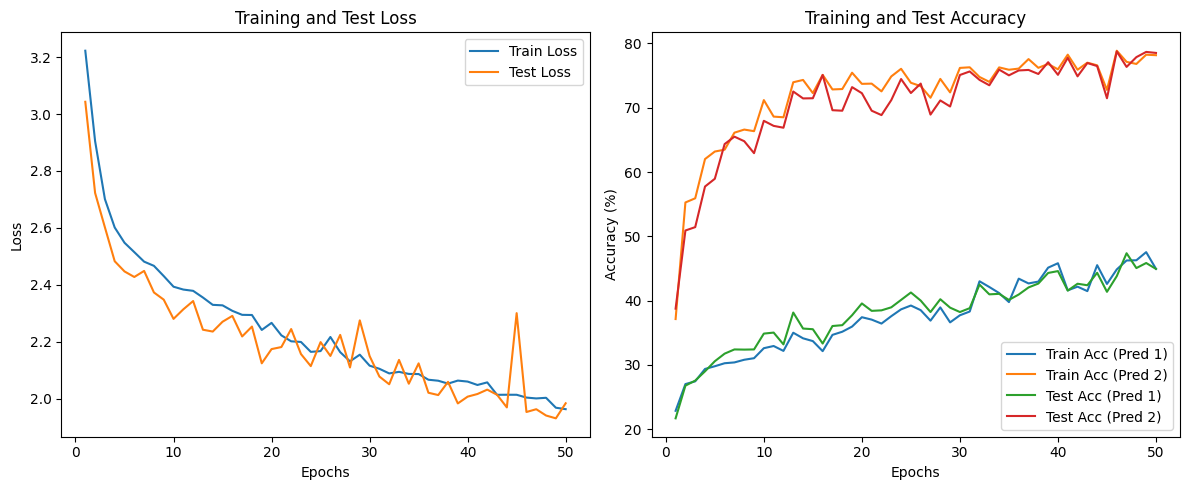

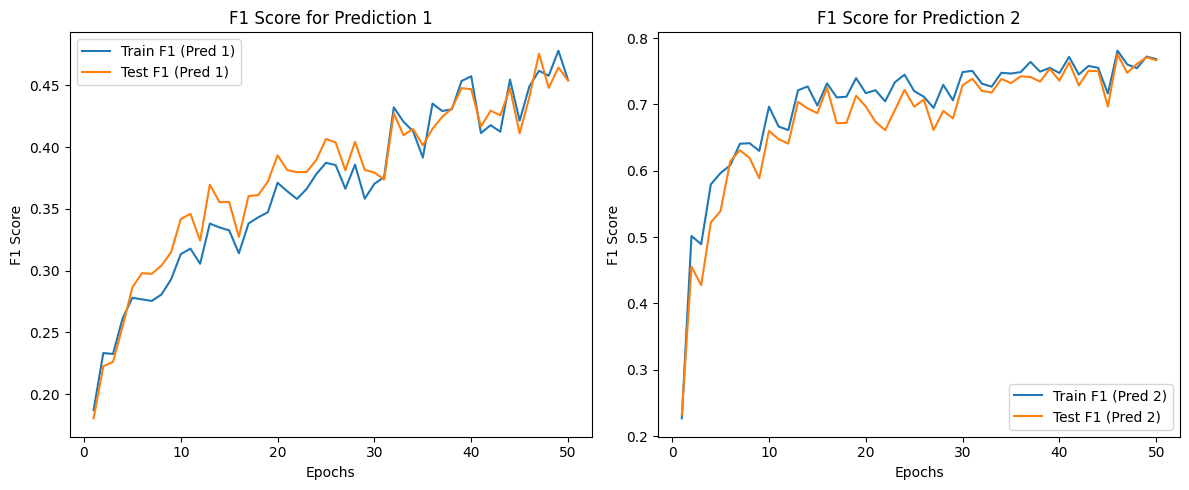

In [31]:
# Import necessary libraries for train-test split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Create train-test split (80% train, 20% test)
train_graphs, test_graphs, train_labels, test_labels = train_test_split(
    graphs_sequences, label_sequences, test_size=0.2, random_state=42
)

print(f"Training set size: {len(train_graphs)} sequences")
print(f"Test set size: {len(test_graphs)} sequences")

# Define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training parameters
num_epochs = 50
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move model to device
model.to(device)

# Lists to store metrics for plotting
train_losses = []
test_losses = []
train_acc1_history = []
train_acc2_history = []
test_acc1_history = []
test_acc2_history = []
train_f1_1_history = []
train_f1_2_history = []
test_f1_1_history = []
test_f1_2_history = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    # Iterate through each sequence in the training dataset
    for i, graph_sequence in enumerate(train_graphs):
        # Move graphs to device
        for j in range(len(graph_sequence)):
            graph_sequence[j] = graph_sequence[j].to(device)
        
        # Get labels for this sequence
        label1 = []
        label2 = []
        for label in train_labels[i]:
            label1.append(label[0])
            label2.append(label[1])

        labels1 = torch.tensor(label1, dtype=torch.long).to(device)
        labels2 = torch.tensor(label2, dtype=torch.long).to(device)
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        pred1, pred2 = model(graph_sequence)
        
        # Calculate loss (using first prediction for now)
        loss1 = criterion(pred1, labels1)
        loss2 = criterion(pred2, labels2)
        
        # Backward pass and optimize
        loss = loss1 + loss2
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Calculate average training loss for this epoch
    avg_train_loss = total_loss / len(train_graphs)
    train_losses.append(avg_train_loss)
    
    # Evaluate on training set
    model.eval()
    train_correct1 = 0
    train_correct2 = 0
    train_total = 0
    all_train_labels1 = []
    all_train_preds1 = []
    all_train_labels2 = []
    all_train_preds2 = []
    
    with torch.no_grad():
        for i, graph_sequence in enumerate(train_graphs):
            # Move graphs to device
            for j in range(len(graph_sequence)):
                graph_sequence[j] = graph_sequence[j].to(device)
            
            # Get labels for this sequence
            label1 = []
            label2 = []
            for label in train_labels[i]:
                label1.append(label[0])
                label2.append(label[1])

            labels1 = torch.tensor(label1, dtype=torch.long).to(device)
            labels2 = torch.tensor(label2, dtype=torch.long).to(device)
            
            # Forward pass
            pred1, pred2 = model(graph_sequence)
            
            # Get predictions
            _, predicted1 = torch.max(pred1.data, 1)
            _, predicted2 = torch.max(pred2.data, 1)
            
            # Update statistics
            train_total += labels1.size(0)
            train_correct1 += (predicted1 == labels1).sum().item()
            train_correct2 += (predicted2 == labels2).sum().item()
            
            # Collect all predictions and labels for F1 score
            all_train_labels1.extend(labels1.cpu().numpy())
            all_train_preds1.extend(predicted1.cpu().numpy())
            all_train_labels2.extend(labels2.cpu().numpy())
            all_train_preds2.extend(predicted2.cpu().numpy())
    
    # Calculate training accuracies
    train_acc1 = 100 * train_correct1 / train_total
    train_acc2 = 100 * train_correct2 / train_total
    train_acc1_history.append(train_acc1)
    train_acc2_history.append(train_acc2)
    
    # Calculate F1 scores for training
    train_f1_1 = f1_score(all_train_labels1, all_train_preds1, average='weighted')
    train_f1_2 = f1_score(all_train_labels2, all_train_preds2, average='weighted')
    train_f1_1_history.append(train_f1_1)
    train_f1_2_history.append(train_f1_2)
    
    # Evaluate on test set
    test_loss = 0
    test_correct1 = 0
    test_correct2 = 0
    test_total = 0
    all_test_labels1 = []
    all_test_preds1 = []
    all_test_labels2 = []
    all_test_preds2 = []
    
    with torch.no_grad():
        for i, graph_sequence in enumerate(test_graphs):
            # Move graphs to device
            for j in range(len(graph_sequence)):
                graph_sequence[j] = graph_sequence[j].to(device)
            
            # Get labels for this sequence
            label1 = []
            label2 = []
            for label in test_labels[i]:
                label1.append(label[0])
                label2.append(label[1])

            labels1 = torch.tensor(label1, dtype=torch.long).to(device)
            labels2 = torch.tensor(label2, dtype=torch.long).to(device)
            
            # Forward pass
            pred1, pred2 = model(graph_sequence)
            
            # Calculate test loss
            loss1 = criterion(pred1, labels1)
            loss2 = criterion(pred2, labels2)
            test_loss += (loss1 + loss2).item()
            
            # Get predictions
            _, predicted1 = torch.max(pred1.data, 1)
            _, predicted2 = torch.max(pred2.data, 1)
            
            # Update statistics
            test_total += labels1.size(0)
            test_correct1 += (predicted1 == labels1).sum().item()
            test_correct2 += (predicted2 == labels2).sum().item()
            
            # Collect all predictions and labels for F1 score
            all_test_labels1.extend(labels1.cpu().numpy())
            all_test_preds1.extend(predicted1.cpu().numpy())
            all_test_labels2.extend(labels2.cpu().numpy())
            all_test_preds2.extend(predicted2.cpu().numpy())
    
    # Calculate test metrics
    avg_test_loss = test_loss / len(test_graphs)
    test_losses.append(avg_test_loss)
    test_acc1 = 100 * test_correct1 / test_total
    test_acc2 = 100 * test_correct2 / test_total
    test_acc1_history.append(test_acc1)
    test_acc2_history.append(test_acc2)
    
    # Calculate F1 scores for test
    test_f1_1 = f1_score(all_test_labels1, all_test_preds1, average='weighted')
    test_f1_2 = f1_score(all_test_labels2, all_test_preds2, average='weighted')
    test_f1_1_history.append(test_f1_1)
    test_f1_2_history.append(test_f1_2)
    
    # Print epoch statistics
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')
    print(f'Train Acc1: {train_acc1:.2f}%, Train Acc2: {train_acc2:.2f}%, Test Acc1: {test_acc1:.2f}%, Test Acc2: {test_acc2:.2f}%')
    print(f'Train F1-1: {train_f1_1:.4f}, Train F1-2: {train_f1_2:.4f}, Test F1-1: {test_f1_1:.4f}, Test F1-2: {test_f1_2:.4f}')

# Final evaluation
model.eval()
correct1 = 0
correct2 = 0
total = 0
all_final_labels1 = []
all_final_preds1 = []
all_final_labels2 = []
all_final_preds2 = []

with torch.no_grad():
    for i, graph_sequence in enumerate(test_graphs):
        # Move graphs to device
        for j in range(len(graph_sequence)):
            graph_sequence[j] = graph_sequence[j].to(device)
        
        # Get labels for this sequence
        label1 = []
        label2 = []
        for label in test_labels[i]:
            label1.append(label[0])
            label2.append(label[1])

        labels1 = torch.tensor(label1, dtype=torch.long).to(device)
        labels2 = torch.tensor(label2, dtype=torch.long).to(device)
        
        # Forward pass
        pred1, pred2 = model(graph_sequence)
        
        # Get predictions
        _, predicted1 = torch.max(pred1.data, 1)
        _, predicted2 = torch.max(pred2.data, 1)
        
        # Update statistics
        total += labels1.size(0)
        correct1 += (predicted1 == labels1).sum().item()
        correct2 += (predicted2 == labels2).sum().item()
        
        # Collect all predictions and labels for F1 score
        all_final_labels1.extend(labels1.cpu().numpy())
        all_final_preds1.extend(predicted1.cpu().numpy())
        all_final_labels2.extend(labels2.cpu().numpy())
        all_final_preds2.extend(predicted2.cpu().numpy())

final_acc1 = 100 * correct1 / total
final_acc2 = 100 * correct2 / total
final_f1_1 = f1_score(all_final_labels1, all_final_preds1, average='weighted')
final_f1_2 = f1_score(all_final_labels2, all_final_preds2, average='weighted')

print(f'Final Test Accuracy for prediction 1: {final_acc1:.2f}%')
print(f'Final Test Accuracy for prediction 2: {final_acc2:.2f}%')
print(f'Final Test F1 Score for prediction 1: {final_f1_1:.4f}')
print(f'Final Test F1 Score for prediction 2: {final_f1_2:.4f}')

# Plot the training and test loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()

# Plot the training and test accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_acc1_history, label='Train Acc (Pred 1)')
plt.plot(range(1, num_epochs+1), train_acc2_history, label='Train Acc (Pred 2)')
plt.plot(range(1, num_epochs+1), test_acc1_history, label='Test Acc (Pred 1)')
plt.plot(range(1, num_epochs+1), test_acc2_history, label='Test Acc (Pred 2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Plot F1 scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_f1_1_history, label='Train F1 (Pred 1)')
plt.plot(range(1, num_epochs+1), test_f1_1_history, label='Test F1 (Pred 1)')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score for Prediction 1')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_f1_2_history, label='Train F1 (Pred 2)')
plt.plot(range(1, num_epochs+1), test_f1_2_history, label='Test F1 (Pred 2)')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score for Prediction 2')
plt.legend()

plt.tight_layout()
plt.show()  


In [35]:
# Save the trained model
torch.save(model.state_dict(), 'trained_model.pth')


In [36]:
next_direction=[67.10,44.93,42.37,44.36,50.12,62.13,61.04,60.11]
speed_change=[82.89,78.52,65.79,66.89,73.89,78.52,75.19,76.45]
model_type=["LSTM Alap","GRU","Less Neuron","More neuron, more layer,Mean aggregation","Less Neuron","Mean aggregation használata","Sum aggregation használata","Max aggregation használata"]
column=["Model Type","Next Direction","Speed Change"]
df=pd.DataFrame(list(zip(model_type,next_direction,speed_change)),columns=column)
df['Average'] = df[['Next Direction', 'Speed Change']].mean(axis=1)
df_sorted = df.sort_values(by='Average', ascending=False)
df_sorted

,Model Type,Next Direction,Speed Change,Average
0,LSTM Alap,67.10,82.89,74.995
5,Mean aggregation használata,62.13,78.52,70.325
7,Max aggregation használata,60.11,76.45,68.280
6,Sum aggregation használata,61.04,75.19,68.115
4,Less Neuron,50.12,73.89,62.005
1,GRU,44.93,78.52,61.725
3,"More neuron, more layer,Mean aggregation",44.36,66.89,55.625
2,Less Neuron,42.37,65.79,54.080
